# Visión artificial

---

## Objetivos

## Manejo de imagenes en python

In [ ]:
#!pip install gradio

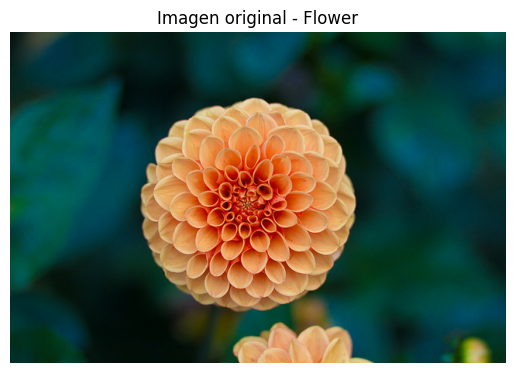

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import gradio as gr
import tensorflow as tf
from PIL import Image
import seaborn as sns
from sklearn.datasets import load_sample_image
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models


In [ ]:

# Cargamos una imagen de ejemplo ("flower.jpg")
flower = load_sample_image("flower.jpg")

# Mostramos la imagen original
plt.imshow(flower)
plt.title("Imagen original - Flower")
plt.axis("off")
plt.show()

In [5]:
# 🔹 2. Convertir la imagen a objeto PIL y explorarla
img_pil = Image.fromarray(china)
print("Formato:", img_pil.format)
print("Tamaño (ancho, alto):", img_pil.size)
print("Modo de color:", img_pil.mode)

# Mostrar la imagen desde PIL
img_pil.show()


Formato: None
Tamaño (ancho, alto): (640, 427)
Modo de color: RGB


In [6]:
# 🔹 3. Convertir la imagen a arreglo NumPy (matriz RGB)
img_array = np.array(img_pil)
print("Forma del array:", img_array.shape)

# Visualizar el array de forma parcial
print("Valores RGB de los primeros 3 píxeles:")
print(img_array[0, :3, :])  # fila 0, primeros 3 píxeles, todos los canales


Forma del array: (427, 640, 3)
Valores RGB de los primeros 3 píxeles:
[[ 2 19 13]
 [ 3 18 13]
 [ 7 20 13]]


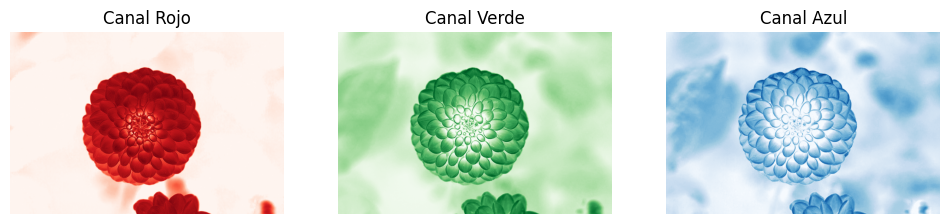

In [7]:
# 🔹 4. Separar y visualizar los canales de color
R = img_array[:, :, 0]  # Canal rojo
G = img_array[:, :, 1]  # Canal verde
B = img_array[:, :, 2]  # Canal azul

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(R, cmap='Reds')
axes[0].set_title("Canal Rojo")
axes[1].imshow(G, cmap='Greens')
axes[1].set_title("Canal Verde")
axes[2].imshow(B, cmap='Blues')
axes[2].set_title("Canal Azul")

for ax in axes:
    ax.axis("off")
plt.show()


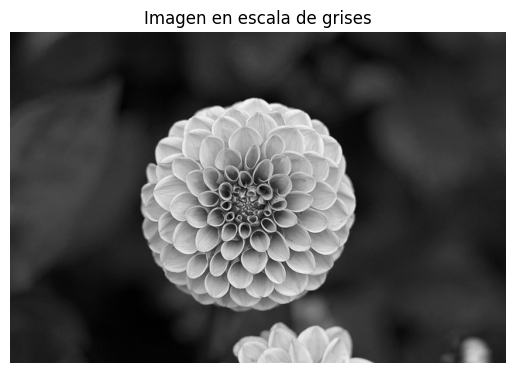

array([[13, 13, 15, 16, 16],
       [12, 13, 15, 16, 17],
       [12, 14, 15, 15, 16],
       [13, 15, 15, 15, 16],
       [15, 16, 16, 16, 16]], dtype=uint8)

In [8]:
# 🔹 5. Manipulación simple: convertir a escala de grises
gray = img_pil.convert("L")

plt.imshow(gray, cmap='gray')
plt.title("Imagen en escala de grises")
plt.axis("off")
plt.show()

# También puedes observarla como matriz:
np.array(gray)[:5, :5]  # muestra los primeros valores de intensidad


## Modelo de clasificación de imagenes

### Redes convolucionales

In [ ]:
# Cargar el dataset MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

In [ ]:
# Visualizar algunos ejemplos del dataset
plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Etiqueta: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Normalizar y redimensionar las imágenes
# CNN espera entradas de 4 dimensiones: (n_imágenes, alto, ancho, canales)

X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

In [ ]:
#Crear el modelo CNN con Keras
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 clases (dígitos 0–9)
])

model.summary()

In [ ]:
# Compilar y entrenar el modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_test, y_test))

In [ ]:
#Evaluar el modelo
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Exactitud en el conjunto de prueba: {test_acc:.4f}")


In [ ]:
#Visualizar la evolución del entrenamiento
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend()
plt.title('Evolución del desempeño')
plt.show()

In [ ]:
#Obtener predicciones sobre el conjunto de prueba
y_pred = np.argmax(model.predict(X_test), axis=1)

# matriz de confusión
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalizada por clase

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar=True,
    xticklabels=[str(i) for i in range(10)],
    yticklabels=[str(i) for i in range(10)],
    linewidths=1,
    linecolor='white'
)

#Etiquetas y estilo
plt.title("📊 Matriz de Confusión Normalizada - MNIST", fontsize=14, weight='bold')
plt.xlabel("Predicción del modelo", fontsize=12)
plt.ylabel("Etiqueta verdadera", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


### Probar el modelo

In [ ]:
iface = gr.Interface(
    fn=predecir_digito,
    inputs=gr.Sketchpad(
        crop_size=(256, 256),
        type="numpy",
        image_mode="L",   # Escala de grises
        brush=gr.Brush(), # Permite dibujar
        label="Dibuja un número (0–9)"
    ),
    outputs=gr.Textbox(),
    title="🖍️ Dibuja un número y deja que la red lo adivine",
    description="Red convolucional simple entrenada con MNIST."
)

iface.launch(inline=True, debug=True)

## Para cerrar 💬🤔

----

1. Explica en tus palabras los conceptos de:
    - Bolsa de palabras
    - Tf-IdF
    - Embbedings
2. Cómo agregarías más características para el modelo `wines prediction`

## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta el proyecto nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [Sprint 17](https://discord.com/channels/1081207584104656986/1270074296395497513).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal `#project` para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨